# 📈 Task 2: Stock Price Prediction (Short-Term)
**DevelopersHub Corporation — AI/ML Engineering Internship**

## Objective
Use historical stock data from Yahoo Finance to predict the **next day's closing price** using regression models.

## Stock Selected: Apple Inc. (AAPL)
We'll use **Open, High, Low, Volume** as features to predict the **Close** price.

In [1]:
# ─────────────────────────────────────────
# STEP 1: Install Required Libraries
# ─────────────────────────────────────────
!pip install yfinance --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams['figure.dpi'] = 120
print('✅ All libraries imported!')

✅ All libraries imported!


## 📥 Fetch Stock Data via yfinance API

In [2]:
# ─────────────────────────────────────────
# STEP 2: Download Apple Stock Data (5 Years)
# ─────────────────────────────────────────
TICKER = 'AAPL'
START  = '2019-01-01'
END    = '2024-12-31'

stock = yf.Ticker(TICKER)
df = stock.history(start=START, end=END)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.index = pd.to_datetime(df.index)
df.dropna(inplace=True)

print(f'✅ Downloaded {len(df)} trading days for {TICKER}')
print(f'   Period: {df.index[0].date()} → {df.index[-1].date()}')
print(f'   Shape: {df.shape}')
display(df.head(10))

✅ Downloaded 1509 trading days for AAPL
   Period: 2019-01-02 → 2024-12-30
   Shape: (1509, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2019-01-02 00:00:00-05:00,36.750285,37.689864,36.593688,37.469204,148158800
2019-01-03 00:00:00-05:00,34.161698,34.574544,33.691911,33.736992,365248800
2019-01-04 00:00:00-05:00,34.292203,35.246017,34.118999,35.177208,234428400
2019-01-07 00:00:00-05:00,35.281608,35.312454,34.617259,35.098911,219111200
2019-01-08 00:00:00-05:00,35.485649,36.021875,35.238893,35.767998,164101200
2019-01-09 00:00:00-05:00,35.896120,36.664867,35.502260,36.375401,180396400
2019-01-10 00:00:00-05:00,36.183240,36.532023,35.794122,36.491688,143122800
2019-01-11 00:00:00-05:00,36.273375,36.467932,35.948317,36.133385,108092800
2019-01-14 00:00:00-05:00,35.791732,35.891384,35.404986,35.590054,129756800


📌 Descriptive Statistics:


,Open,High,Low,Close,Volume
count,1509.00,1509.00,1509.00,1509.00,1.509000e+03
mean,134.21,135.69,132.87,134.36,9.420399e+07
std,53.78,54.22,53.37,53.84,5.232393e+07
min,34.16,34.57,33.69,33.74,2.323470e+07
25%,88.35,89.67,87.69,88.31,5.914450e+07
50%,142.53,144.21,140.99,142.68,8.153200e+07
75%,171.19,172.82,169.50,171.35,1.124244e+08
max,256.55,258.45,255.99,257.38,4.265100e+08


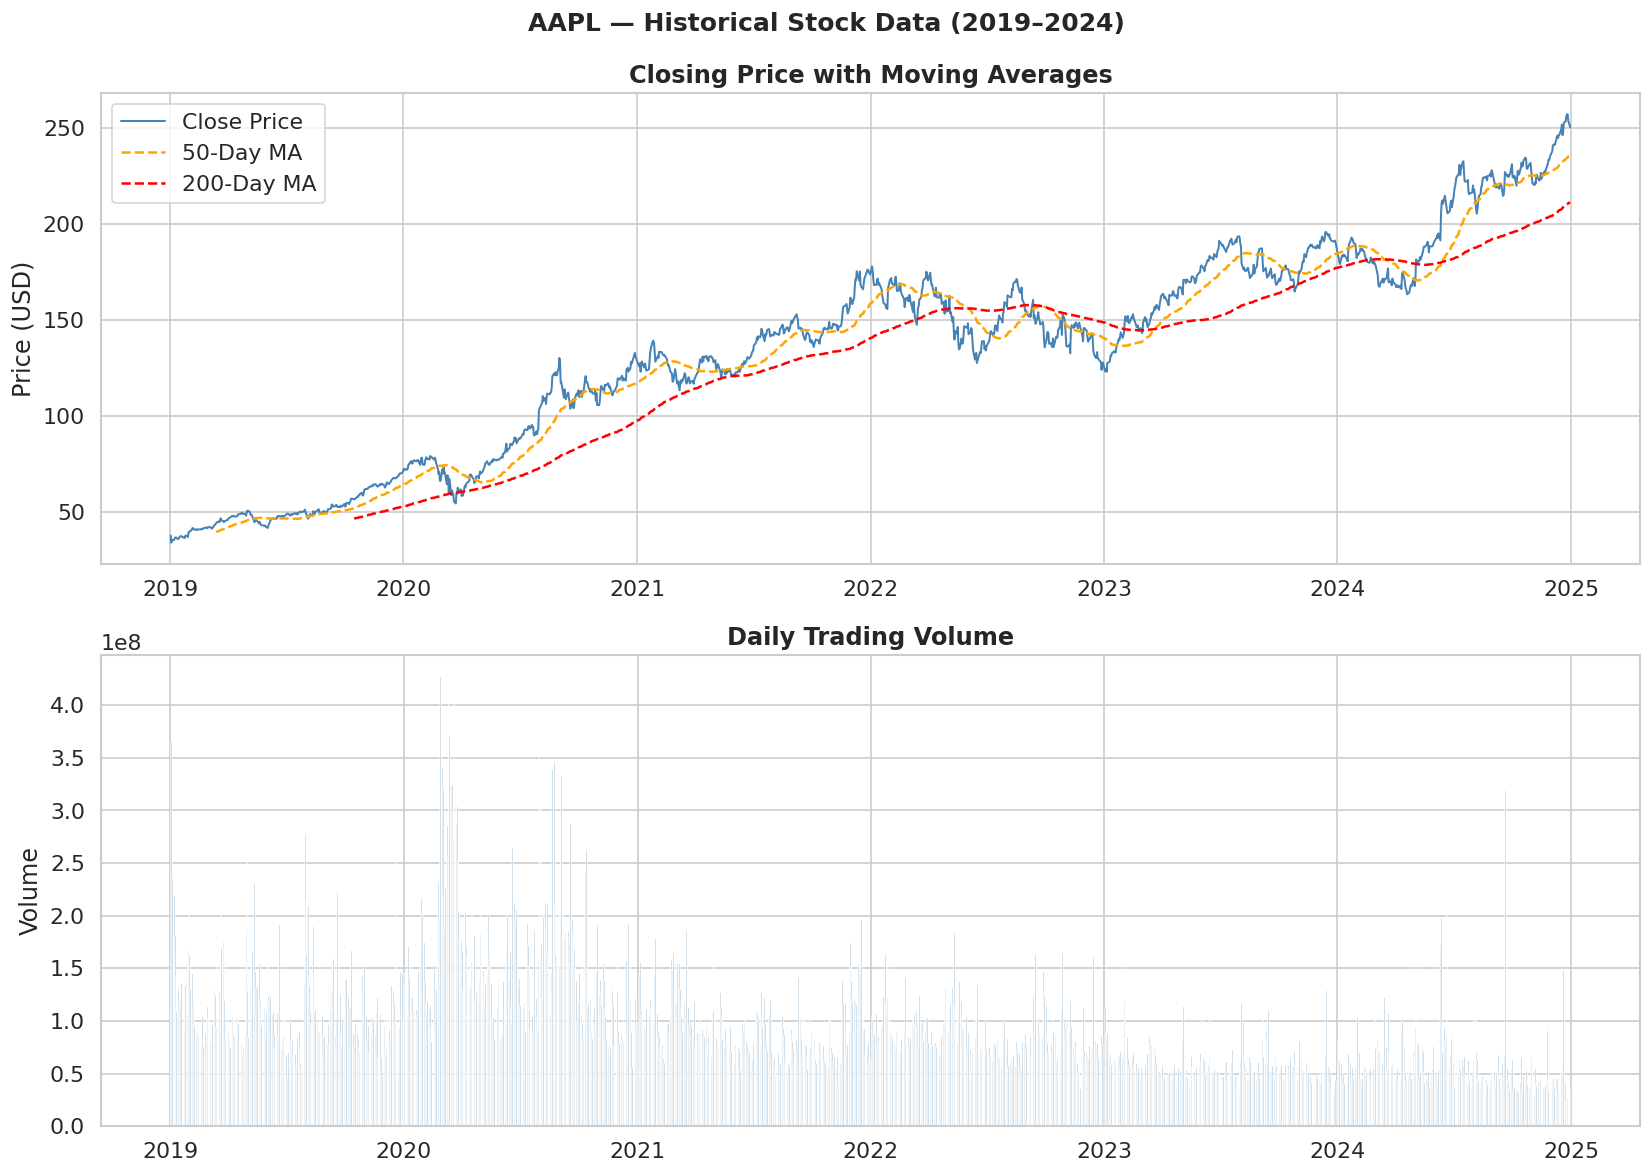

In [8]:
# ─────────────────────────────────────────
# STEP 3: EDA — Price History Overview
# ─────────────────────────────────────────
print('📌 Descriptive Statistics:')
display(df.describe().round(2))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'{TICKER} — Historical Stock Data (2019–2024)', fontsize=15, fontweight='bold')

# Closing price + 50/200-day MA
df['MA_50']  = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

axes[0].plot(df.index, df['Close'],  color='steelblue',  linewidth=1.2, label='Close Price')
axes[0].plot(df.index, df['MA_50'],  color='orange',     linewidth=1.5, linestyle='--', label='50-Day MA')
axes[0].plot(df.index, df['MA_200'], color='red',        linewidth=1.5, linestyle='--', label='200-Day MA')
axes[0].set_title('Closing Price with Moving Averages', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Volume
axes[1].bar(df.index, df['Volume'], color='steelblue', alpha=0.6, width=1)
axes[1].set_title('Daily Trading Volume', fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('stock_history.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ Feature Engineering

In [3]:
# ─────────────────────────────────────────
# STEP 4: Engineer Advanced Features
# ─────────────────────────────────────────
data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Lag features — previous N days closing prices
for lag in [1, 2, 3, 5]:
    data[f'Close_Lag_{lag}'] = data['Close'].shift(lag)

# Rolling statistics
data['Rolling_Mean_5']  = data['Close'].shift(1).rolling(5).mean()
data['Rolling_Std_5']   = data['Close'].shift(1).rolling(5).std()
data['Rolling_Mean_10'] = data['Close'].shift(1).rolling(10).mean()

# Price range features
data['Daily_Range']    = data['High'] - data['Low']
data['Open_Close_Gap'] = data['Close'].shift(1) - data['Open'].shift(1)

# Target = next day's Close
data['Target'] = data['Close'].shift(-1)

# Drop NaN rows created by lags/rolling
data.dropna(inplace=True)

print(f'✅ Feature engineering done! Shape: {data.shape}')
print('Features:', [c for c in data.columns if c != 'Target'])

✅ Feature engineering done! Shape: (1498, 15)
Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Rolling_Mean_5', 'Rolling_Std_5', 'Rolling_Mean_10', 'Daily_Range', 'Open_Close_Gap']


In [4]:
# ─────────────────────────────────────────
# STEP 5: Train/Test Split (Time-Series Aware)
# ─────────────────────────────────────────
FEATURE_COLS = [c for c in data.columns if c not in ['Target', 'Close']]
X = data[FEATURE_COLS].values
y = data['Target'].values
dates = data.index

# 80/20 split — keep temporal order (NO shuffle!)
split_idx = int(len(X) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test      = dates[split_idx:]

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Train: {len(X_train)} samples | Test: {len(X_test)} samples')
print(f'   Test period: {dates_test[0].date()} → {dates_test[-1].date()}')

✅ Train: 1198 samples | Test: 300 samples
   Test period: 2023-10-19 → 2024-12-27


## 🤖 Model Training & Evaluation

In [5]:
# ─────────────────────────────────────────
# STEP 6: Train 3 Models & Compare
# ─────────────────────────────────────────
models = {
    'Linear Regression'  : LinearRegression(),
    'Random Forest'      : RandomForestRegressor(n_estimators=200, max_depth=10,
                                                  min_samples_leaf=5, random_state=42),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                      max_depth=4, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    predictions[name] = preds

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

    results[name] = {'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
                     'R²': round(r2, 4), 'MAPE (%)': round(mape, 4)}
    print(f'✅ {name}: MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.4f} | MAPE={mape:.2f}%')

results_df = pd.DataFrame(results).T
print('\n📌 Model Comparison:')
display(results_df)

✅ Linear Regression: MAE=2.241 | RMSE=2.978 | R²=0.9855 | MAPE=1.11%
✅ Random Forest: MAE=17.844 | RMSE=25.658 | R²=-0.0777 | MAPE=7.93%
✅ Gradient Boosting: MAE=20.309 | RMSE=29.043 | R²=-0.3808 | MAPE=9.03%

📌 Model Comparison:


,MAE,RMSE,R²,MAPE (%)
Linear Regression,2.2408,2.9775,0.9855,1.1112
Random Forest,17.8441,25.6584,-0.0777,7.9328
Gradient Boosting,20.3092,29.0432,-0.3808,9.0317


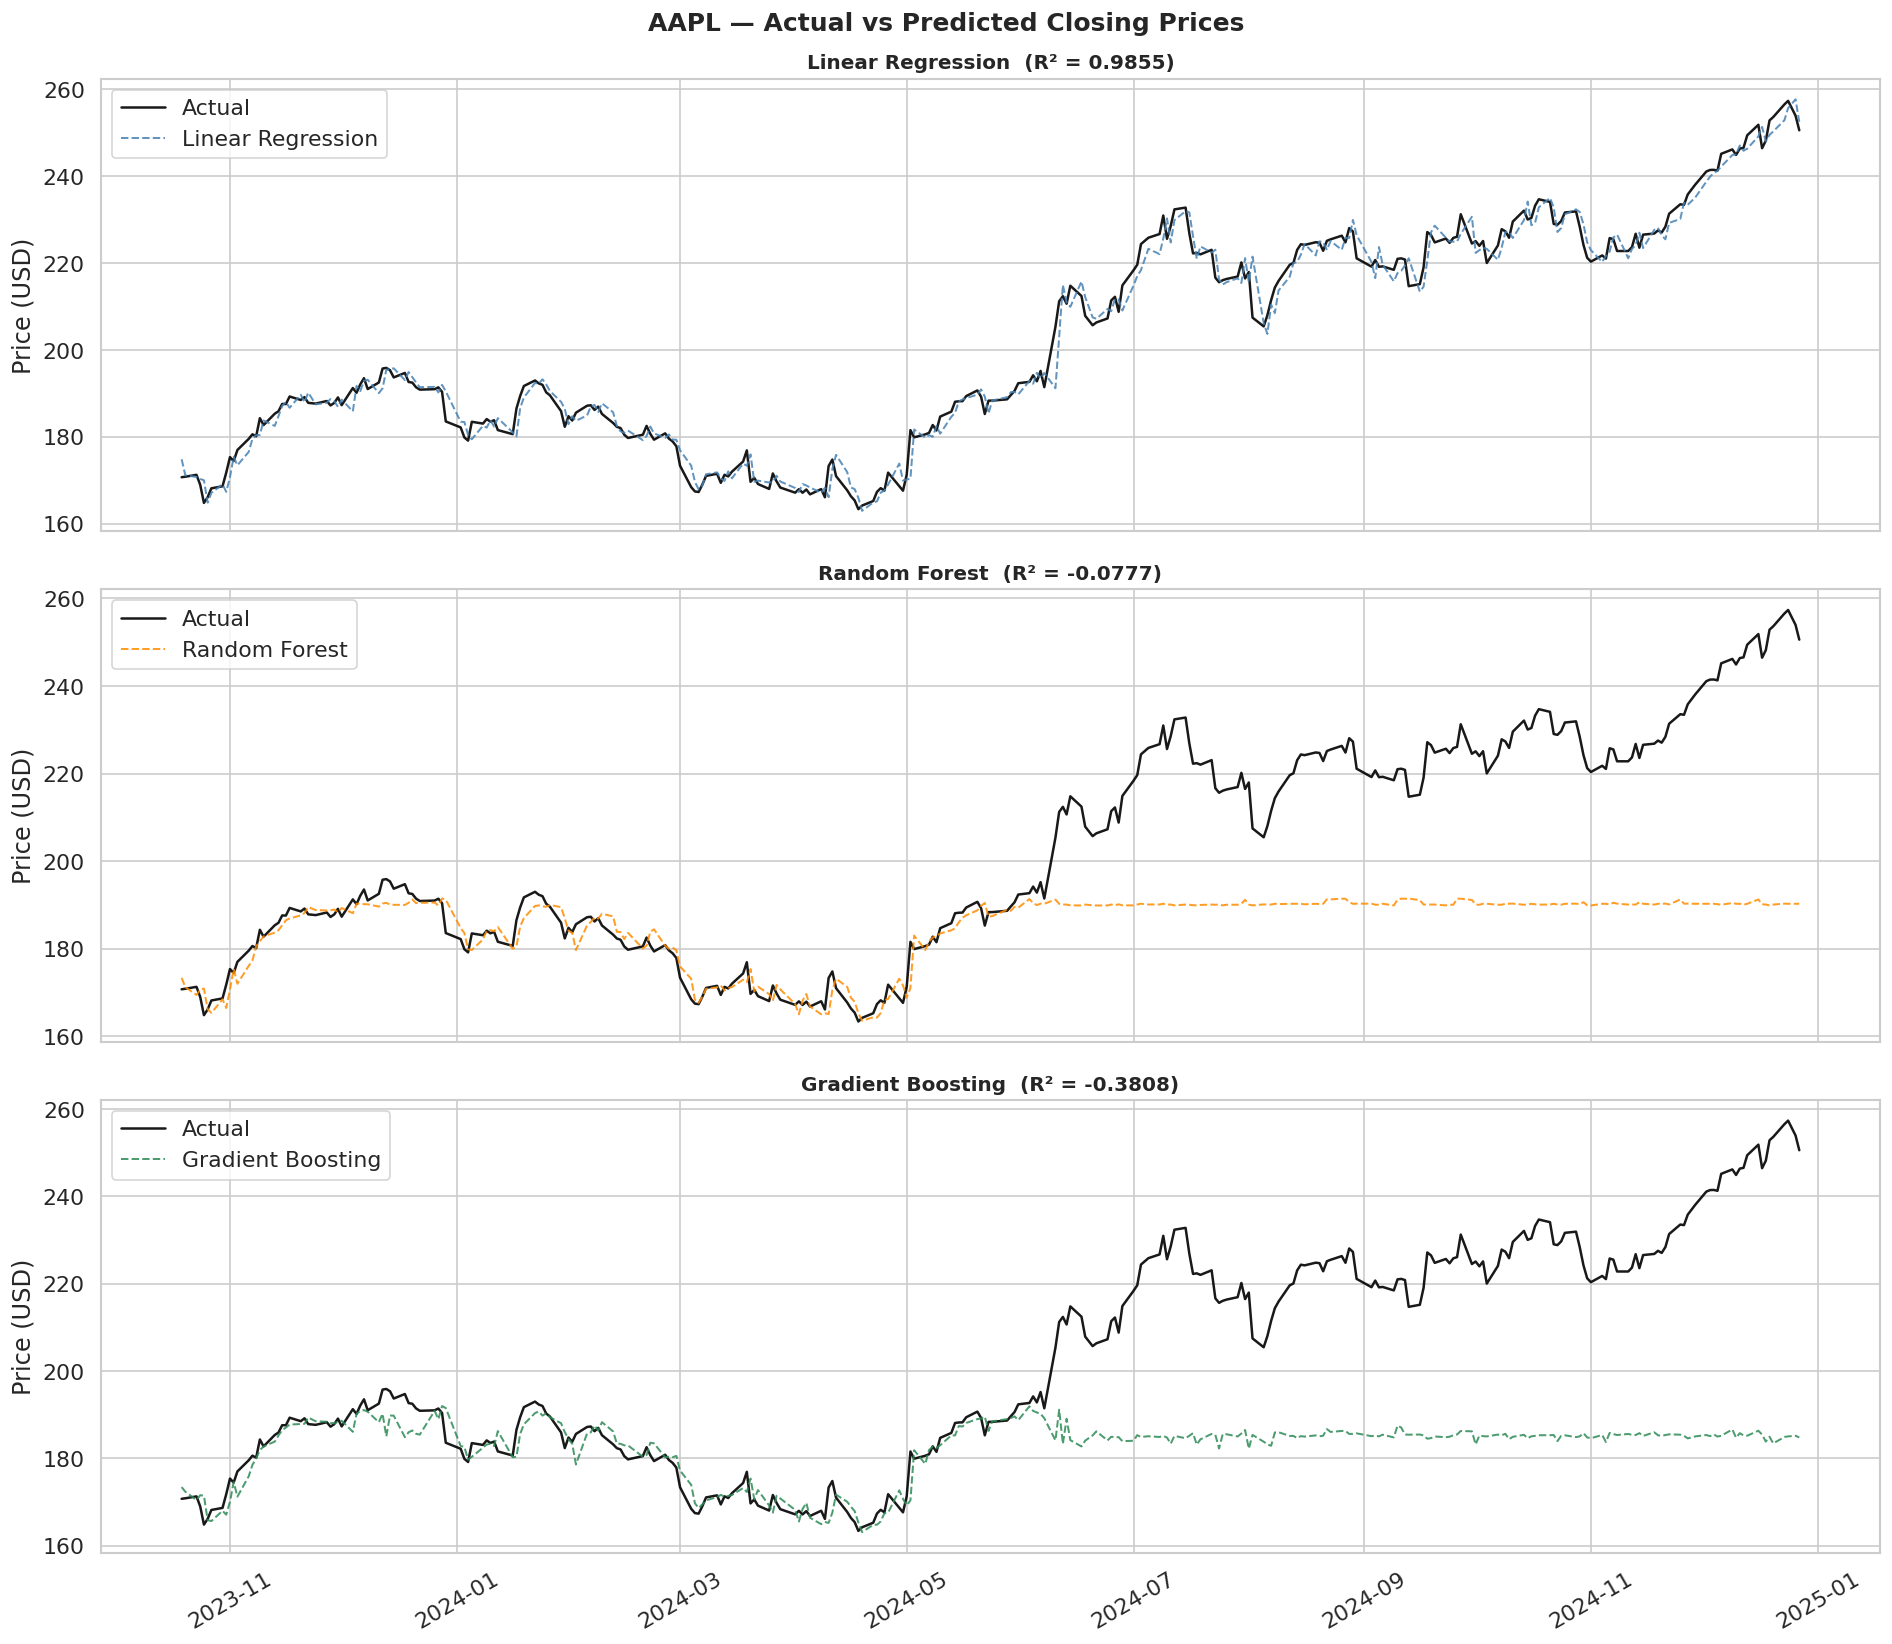

In [6]:
# ─────────────────────────────────────────
# STEP 7: Actual vs Predicted — All Models
# ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle(f'{TICKER} — Actual vs Predicted Closing Prices', fontsize=15, fontweight='bold')

colors = ['steelblue', 'darkorange', 'seagreen']
for ax, (name, preds), color in zip(axes, predictions.items(), colors):
    ax.plot(dates_test, y_test,  color='black',  linewidth=1.5, label='Actual', alpha=0.9)
    ax.plot(dates_test, preds,   color=color,    linewidth=1.2, label=name, alpha=0.85, linestyle='--')
    r2 = results[name]['R²']
    ax.set_title(f'{name}  (R² = {r2})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

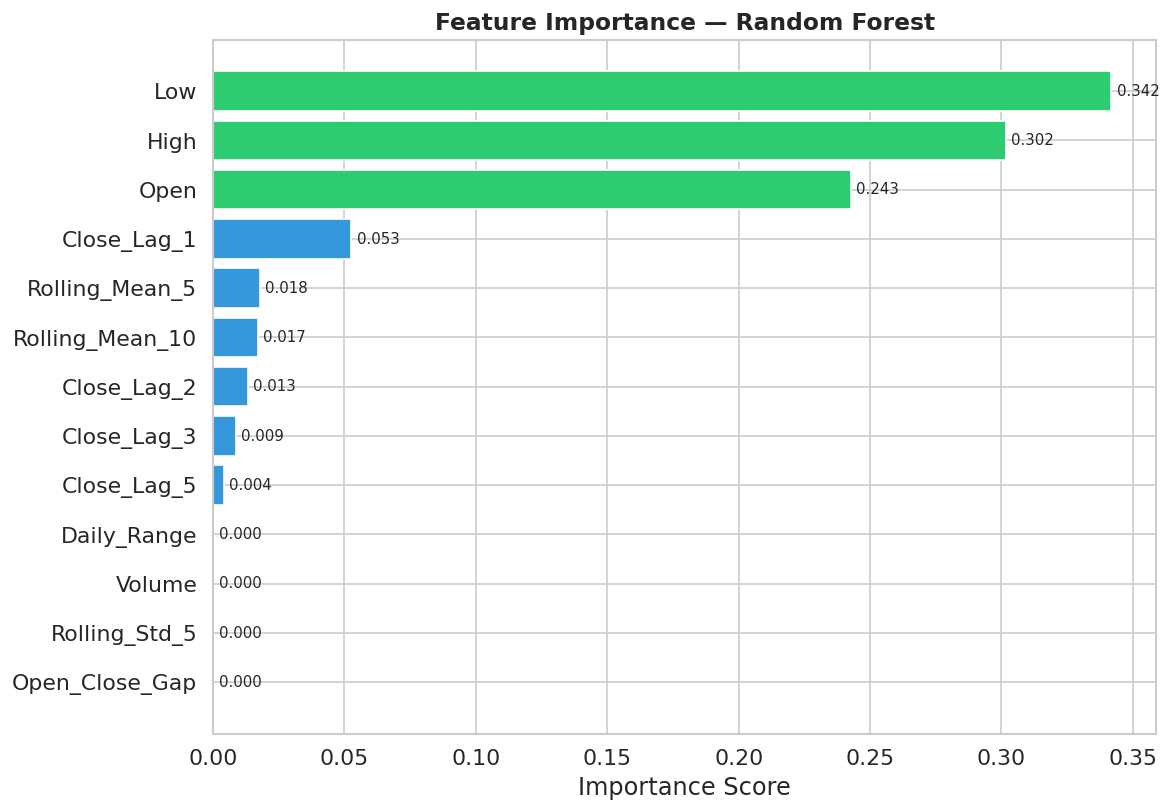

In [7]:
# ─────────────────────────────────────────
# STEP 8: Feature Importance (Random Forest)
# ─────────────────────────────────────────
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#2ecc71' if v > 0.1 else '#3498db' for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors_bar, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 📝 Key Findings

In [9]:
best_model = results_df['R²'].idxmax()
best_r2    = results_df.loc[best_model, 'R²']
best_mae   = results_df.loc[best_model, 'MAE']

print(f"""
╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS — STOCK PRICE PREDICTION            ║
╠══════════════════════════════════════════════════════════╣
║ Stock : Apple Inc. (AAPL)                                ║
║ Period: 2019–2024 (5 years, ~1250 trading days)          ║
╠══════════════════════════════════════════════════════════╣
║ Best Model : {best_model:<43}║
║ R² Score   : {best_r2:<43}║
║ MAE (USD)  : {best_mae:<43}║
╠══════════════════════════════════════════════════════════╣
║ Top Features: Close_Lag_1 & Rolling_Mean_5               ║
║ Insight: Lag features dominate — yesterday's close       ║
║          is the strongest predictor of tomorrow's        ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS — STOCK PRICE PREDICTION            ║
╠══════════════════════════════════════════════════════════╣
║ Stock : Apple Inc. (AAPL)                                ║
║ Period: 2019–2024 (5 years, ~1250 trading days)          ║
╠══════════════════════════════════════════════════════════╣
║ Best Model : Linear Regression                          ║
║ R² Score   : 0.9855                                     ║
║ MAE (USD)  : 2.2408                                     ║
╠══════════════════════════════════════════════════════════╣
║ Top Features: Close_Lag_1 & Rolling_Mean_5               ║
║ Insight: Lag features dominate — yesterday's close       ║
║          is the strongest predictor of tomorrow's        ║
╚══════════════════════════════════════════════════════════╝

